# ResNets (Residual Networks) - Explained

## What This Notebook Covers

This notebook introduces **ResNets** (Residual Networks), one of the most important architectural innovations in deep learning. ResNets enabled training of much deeper networks than previously possible.

### The Deep Network Problem

Before ResNets, there was a puzzling problem:

| Network Depth | Expected Result | Actual Result |
|--------------|-----------------|---------------|
| 20 layers | Good accuracy | Good accuracy |
| 56 layers | Better accuracy | **Worse** accuracy! |

Adding more layers should give at least the same accuracy (the extra layers could just learn identity mappings). But in practice, deeper networks performed **worse**.

### The Solution: Skip Connections

ResNets solve this by adding **skip connections** (also called shortcut connections or residual connections):

```
Traditional:           ResNet:
                       
x ─→ [Conv] ─→ y      x ─→ [Conv] ─→ (+) ─→ y
                           │          ↑
                           └──────────┘
                           (skip connection)
```

### Key Concepts We'll Learn

1. **Why deeper isn't always better** - The degradation problem
2. **Skip connections** - The key innovation
3. **ResBlock** - Building block of ResNets
4. **Identity mapping vs projection** - Handling dimension changes
5. **Using timm** - Pre-built ResNet architectures

Let's dive in!

---
## Part 1: Setup and Imports

In [ ]:
#|default_exp resnet
# This cell marks that code with #|export will be exported to miniai/resnet.py

In [ ]:
#|export
# Standard library imports
import pickle, gzip, math, os, time, shutil
import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt

# Fastcore utilities
import fastcore.all as fc
from collections.abc import Mapping
from pathlib import Path
from operator import attrgetter, itemgetter
from functools import partial
from copy import copy
from contextlib import contextmanager

# PyTorch imports
import torch
import torchvision.transforms.functional as TF
import torch.nn.functional as F
from torch import tensor, nn, optim
from torch.utils.data import DataLoader, default_collate
from torch.nn import init
from torch.optim import lr_scheduler
from torcheval.metrics import MulticlassAccuracy
from datasets import load_dataset, load_dataset_builder

# Our custom modules from previous notebooks
from miniai.datasets import *
from miniai.conv import *
from miniai.learner import *
from miniai.activations import *
from miniai.init import *
from miniai.sgd import *

In [ ]:
from fastcore.test import test_close

# Configure display
torch.set_printoptions(precision=2, linewidth=140, sci_mode=False)
torch.manual_seed(1)
mpl.rcParams['image.cmap'] = 'gray'  # Default colormap for images

# Disable logging warnings
import logging
logging.disable(logging.WARNING)

# Set seed for reproducibility
set_seed(42)

## 🛠️ Interactive visualizations — one-time setup

The cells marked **🎮 Interactive** below embed standalone HTML/JS visualizations
(stored in the `interactive_viz/` folder next to this notebook) at **full width and
~full viewport height**. Run the next cell once, then run any 🎮 cell.

In [ ]:
# ============================================================================
# INTERACTIVE VISUALIZATIONS -- setup (run this cell ONCE).
# Each "🎮 Interactive" cell below loads a standalone HTML file from the
# published copy on GitHub Pages, in an isolated <iframe> (its CSS/JS can't leak
# into the notebook). It is shown FULL WIDTH and auto-fits its content height.
# No local files needed -- the visualizations are read from GitHub.
# ============================================================================
from IPython.display import HTML

def show_viz(path, height="600px"):
    """Embed an interactive visualization full width; it auto-fits its height.
    `path` may be a bare 'interactive_viz/<file>.html' (resolved to the GitHub
    Pages copy) or a full https URL."""
    base = "https://shammun.github.io/shammunul-fastai-notes/notebooks/"
    if not path.startswith("http"):
        path = base + path
    return HTML(
        f'<iframe src="{path}" loading="lazy" allowfullscreen '
        f'style="width:100%;height:{height};border:1px solid #dde5f2;border-radius:12px;'
        f'box-shadow:0 8px 24px rgba(123,92,214,.12);background:#fff;"></iframe>'
        '<script>addEventListener("message",function(e){'
        'if(e.data&&e.data.type==="ce-frame-height"&&e.data.height>50){'
        'var fs=document.querySelectorAll("iframe");for(var i=0;i<fs.length;i++){'
        'if(fs[i].contentWindow===e.source){fs[i].style.height=e.data.height+"px";break;}}}});</script>'
    )

---
## Part 2: Data Setup

We continue using Fashion MNIST with normalized inputs.

In [ ]:
# Dataset configuration
xl, yl = 'image', 'label'  # Column names
name = "zalando-datasets/fashion_mnist"      # Dataset name
bs = 1024                   # Batch size
xmean, xstd = 0.28, 0.35    # Normalization constants

# Transform: convert to tensor and normalize
@inplace
def transformi(b):
    b[xl] = [(TF.to_tensor(o) - xmean) / xstd for o in b[xl]]

# Load dataset and create dataloaders
dsd = load_dataset(name)
tds = dsd.with_transform(transformi)
dls = DataLoaders.from_dd(tds, bs, num_workers=4)

# Understanding `DataLoaders.from_dd()` in miniai

## Origin

`from_dd` is **not** a PyTorch function. It is a custom `@classmethod` defined on the `DataLoaders` class inside the **miniai** library — the mini deep learning framework that Jeremy Howard builds incrementally throughout the fast.ai Part 2 course. It was defined in one of the earlier notebooks (around notebook 05–09) and exported to `miniai.datasets` via nbdev.

## What Does "dd" Stand For?

The **"dd"** in `from_dd` stands for **DatasetDict** — specifically a Hugging Face `datasets.DatasetDict`, which is exactly what `load_dataset()` returns.

## Usage Context

```python
dsd = load_dataset("fashion_mnist")   # returns a DatasetDict with 'train' and 'test' splits
tds = dsd.with_transform(transformi)  # still a DatasetDict, but with lazy transforms
dls = DataLoaders.from_dd(tds, bs, num_workers=4)
```

## What It Does Under the Hood

Here is a reconstructed version of the implementation based on the course pattern:

```python
class DataLoaders:
    def __init__(self, train, valid):
        self.train = train
        self.valid = valid

    @classmethod
    def from_dd(cls, dd, batch_size, **kwargs):
        return cls(
            DataLoader(dd['train'], batch_size=batch_size, shuffle=True,
                       collate_fn=collate_dict(dd['train']), **kwargs),
            DataLoader(dd['test'],  batch_size=batch_size, shuffle=False,
                       collate_fn=collate_dict(dd['test']),  **kwargs)
        )
```

## Step-by-Step Breakdown

1. **Extracts the `'train'` and `'test'` splits** from the Hugging Face `DatasetDict`.

2. **Wraps each in a standard PyTorch `DataLoader`** (from `torch.utils.data`), with `shuffle=True` for training and `shuffle=False` for validation.

3. **Uses a custom `collate_fn`** (likely `collate_dict` or similar, also defined in miniai) because HF datasets return dictionaries (like `{'image': ..., 'label': ...}`) rather than tuples, and PyTorch's `default_collate` needs help to handle that dict format properly.

4. **Bundles both DataLoaders** into a single `DataLoaders` container with `.train` and `.valid` attributes for convenient access in the training loop.

## Why It Exists

It is essentially a convenience factory method that bridges the gap between the **Hugging Face `datasets` ecosystem** (which uses `DatasetDict` with named splits) and **PyTorch's `DataLoader`**, saving you from writing the boilerplate of creating two separate DataLoaders every time.

The fastai v2 library has a similar concept (`DataLoaders.from_dsets`), but the miniai version is a much simpler, stripped-down implementation built specifically for HF datasets.

## Key Distinction from PyTorch and fastai

| Aspect | PyTorch | fastai v2 | miniai |
|---|---|---|---|
| Class | `torch.utils.data.DataLoader` | `fastai.data.core.DataLoaders` | `miniai.datasets.DataLoaders` |
| Factory method | None (manual setup) | `from_dsets`, `from_dblock` | `from_dd` |
| Input format | Any `Dataset` | fastai `Datasets` / `DataBlock` | HF `DatasetDict` |
| Collation | `default_collate` | `fa_collate` | Custom `collate_dict` |
| Complexity | Low-level | Full-featured | Minimal / educational |

In [ ]:
#|export
# GeneralRelu activation (from previous notebooks)
# leak=0.1: Leaky ReLU with 0.1 slope for negatives
# sub=0.4: Subtract 0.4 to center outputs around 0
act_gr = partial(GeneralRelu, leak=0.1, sub=0.4)

In [ ]:
# Setup callbacks
metrics = MetricsCB(accuracy=MulticlassAccuracy())  # Track accuracy
astats = ActivationStats(fc.risinstance(GeneralRelu))  # Monitor activations

# Standard callbacks
cbs = [DeviceCB(), metrics, ProgressCB(plot=True), astats]

# Kaiming initialization for leaky ReLU
iw = partial(init_weights, leaky=0.1)

---
## Part 3: Going Deeper

Let's first try making our network deeper without skip connections.

In [ ]:
def conv(ni, nf, ks=3, stride=2, act=nn.ReLU, norm=None, bias=None):
    if bias is None: bias = not isinstance(norm, (nn.BatchNorm1d,nn.BatchNorm2d,nn.BatchNorm3d))
    layers = [nn.Conv2d(ni, nf, stride=stride, kernel_size=ks, padding=ks//2, bias=bias)]
    if norm: layers.append(norm(nf))
    if act: layers.append(act())
    return nn.Sequential(*layers)

# %% ../nbs/11_initializing.ipynb 115
def get_model(act=nn.ReLU, nfs=None, norm=None):
    if nfs is None: nfs = [1,8,16,32,64]
    layers = [conv(nfs[i], nfs[i+1], act=act, norm=norm) for i in range(len(nfs)-1)]
    return nn.Sequential(*layers, conv(nfs[-1],10, act=None, norm=False, bias=True),
                         nn.Flatten()).to(def_device)

# How Does Appending Activation and Normalization Layers Work in PyTorch's `nn.Sequential`?

## The Confusion

In the `conv()` helper function from miniai, we see lines like:

```python
if norm: layers.append(norm(nf))
if act: layers.append(act())
```

This raises two questions:

1. How are `norm` and `act` being "called" like functions when they are passed in as arguments?
2. How does appending activation to the *end* of a list actually apply it to the convolution output?

## The Core Insight: Classes as Arguments

The key thing to understand is that in Python, **classes are first-class objects**. When you write `act=nn.ReLU`, you are not creating a ReLU — you are passing the *class itself* as an argument. The parentheses `()` come later to *instantiate* it.

So there are two distinct moments:

```python
nn.ReLU      # This is the class (a blueprint) — no parentheses
nn.ReLU()    # This is an instance (an actual object) — with parentheses
```

## The `conv()` Function

```python
def conv(ni, nf, ks=3, stride=2, act=nn.ReLU, norm=None, bias=None):
    if bias is None: bias = not isinstance(norm, (nn.BatchNorm1d,nn.BatchNorm2d,nn.BatchNorm3d))
    layers = [nn.Conv2d(ni, nf, stride=stride, kernel_size=ks, padding=ks//2, bias=bias)]
    if norm: layers.append(norm(nf))
    if act: layers.append(act())
    return nn.Sequential(*layers)
```

### How `if act: layers.append(act())` Works

Inside `conv()`, the parameter `act` holds a **reference to a class** (like `nn.ReLU`). When you write `act()`, you are calling that class's constructor — equivalent to writing `nn.ReLU()`. So:

```python
act = nn.ReLU    # act now points to the ReLU class
act()            # same as nn.ReLU() — creates a ReLU instance
```

The `if act:` guard handles the case where `act=None` is passed (meaning "no activation wanted"). Since `None` is falsy and class references are truthy, this elegantly skips the activation when not needed.

The layers list after this might look like:

```python
layers = [
    nn.Conv2d(1, 8, kernel_size=3, stride=2, padding=1),   # the convolution
    nn.ReLU()                                                # the activation
]
```

### How `if norm: layers.append(norm(nf))` Works

Same pattern, but `norm` is a normalization class like `nn.BatchNorm2d`, and it needs an argument — the number of features:

```python
norm = nn.BatchNorm2d   # the class itself
norm(nf)                # same as nn.BatchNorm2d(nf) — e.g., nn.BatchNorm2d(8)
```

So layers becomes:

```python
layers = [
    nn.Conv2d(1, 8, kernel_size=3, stride=2, padding=1),   # convolution
    nn.BatchNorm2d(8),                                       # normalization
    nn.ReLU()                                                # activation
]
```

## Why Appending to the End of the List Works

This is where `nn.Sequential` does its magic. When you write:

```python
return nn.Sequential(*layers)
```

PyTorch chains these layers so that **the output of each layer becomes the input to the next**, in order. So during a forward pass:

```
Input tensor x
    → passes through nn.Conv2d(1, 8, ...)     → produces feature maps
    → passes through nn.BatchNorm2d(8)         → normalizes those feature maps
    → passes through nn.ReLU()                 → applies activation element-wise
    → output tensor
```

The activation is not being applied "on" the Conv2d layer in some internal way — it is a **separate layer that processes the output of the previous layer**. This is functionally identical to writing:

```python
x = conv(x)
x = batchnorm(x)
x = relu(x)
```

## Tracing Through `get_model()`

```python
def get_model(act=nn.ReLU, nfs=None, norm=None):
    if nfs is None: nfs = [1,8,16,32,64]
    layers = [conv(nfs[i], nfs[i+1], act=act, norm=norm) for i in range(len(nfs)-1)]
    return nn.Sequential(*layers, conv(nfs[-1],10, act=None, norm=False, bias=True),
                         nn.Flatten()).to(def_device)
```

With default arguments (`act=nn.ReLU`, `norm=None`), the list comprehension produces 4 blocks:

| `i` | `conv(ni, nf)` | What Gets Built (norm=None, so no BatchNorm) |
|-----|----------------|----------------------------------------------|
| 0   | `conv(1, 8)`   | `Sequential(Conv2d(1→8), ReLU())`            |
| 1   | `conv(8, 16)`  | `Sequential(Conv2d(8→16), ReLU())`           |
| 2   | `conv(16, 32)` | `Sequential(Conv2d(16→32), ReLU())`          |
| 3   | `conv(32, 64)` | `Sequential(Conv2d(32→64), ReLU())`          |

Then the final `conv(64, 10, act=None, norm=False, bias=True)` produces just a bare `Conv2d(64→10)` with no activation and no normalization — because this is the output layer that produces raw logits.

### Full Model Architecture (default arguments)

```
Sequential(
  Sequential(Conv2d(1→8),   ReLU()),
  Sequential(Conv2d(8→16),  ReLU()),
  Sequential(Conv2d(16→32), ReLU()),
  Sequential(Conv2d(32→64), ReLU()),
  Sequential(Conv2d(64→10)),              # no activation — raw logits
  Flatten()                                # flatten for cross-entropy loss
)
```

### Full Model Architecture (with `norm=nn.BatchNorm2d`)

If you call `get_model(act=nn.ReLU, norm=nn.BatchNorm2d)`, each inner block becomes `Sequential(Conv2d, BatchNorm2d, ReLU)` instead — and the bias in Conv2d automatically turns off because of the `if bias is None` logic (since BatchNorm has its own learnable bias, a separate conv bias would be redundant).

```
Sequential(
  Sequential(Conv2d(1→8, bias=False),   BatchNorm2d(8),  ReLU()),
  Sequential(Conv2d(8→16, bias=False),  BatchNorm2d(16), ReLU()),
  Sequential(Conv2d(16→32, bias=False), BatchNorm2d(32), ReLU()),
  Sequential(Conv2d(32→64, bias=False), BatchNorm2d(64), ReLU()),
  Sequential(Conv2d(64→10, bias=True)),    # no activation — raw logits
  Flatten()                                 # flatten for cross-entropy loss
)
```

## Summary

This is a clean design pattern — passing **classes as arguments** lets you swap architectures (different activations, different normalizations) without rewriting the model builder. The `nn.Sequential` container takes care of chaining the layers so that data flows through them in order, making "appending to the end of a list" equivalent to "apply this operation next in the forward pass."

In [ ]:
def get_model(act=nn.ReLU, nfs=(8, 16, 32, 64, 128), norm=nn.BatchNorm2d):
    """
    Create a deep CNN without skip connections.
    
    This is a straightforward stack of convolutional layers.
    
    Args:
        act: Activation function class (default: nn.ReLU)
        nfs: Tuple of filter counts for each layer (default: (8,16,32,64,128))
        norm: Normalization layer class (default: nn.BatchNorm2d)
    
    Returns:
        nn.Sequential model
    
    Architecture:
        Input: 1x28x28 (grayscale Fashion MNIST)
        
        conv(1→8, stride=1)   # 28x28 → 28x28 (no downsampling)
        conv(8→16, stride=2)  # 28x28 → 14x14
        conv(16→32, stride=2) # 14x14 → 7x7
        conv(32→64, stride=2) # 7x7 → 4x4
        conv(64→128, stride=2)# 4x4 → 2x2
        conv(128→10)          # 2x2 → 1x1 (10 classes)
        Flatten()             # Output: 10
    """
    # First layer: keep spatial dimensions (stride=1)
    layers = [conv(1, 8, stride=1, act=act, norm=norm)]
    
    # Add layers with stride=2 (halves spatial dimensions each time)
    layers += [conv(nfs[i], nfs[i+1], act=act, norm=norm) 
               for i in range(len(nfs)-1)]
    
    # Final conv to 10 classes + flatten
    return nn.Sequential(
        *layers, 
        conv(nfs[-1], 10, act=None, norm=norm, bias=True), 
        nn.Flatten()
    ).to(def_device)

In [ ]:
# Train the deep model without skip connections
set_seed(42)
lr, epochs = 6e-2, 5

# Create model with GeneralRelu and BatchNorm
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)

# 1cycle learning rate schedule
tmax = epochs * len(dls.train)
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)
xtra = [BatchSchedCB(sched)]

# Create learner with AdamW optimizer
learn = TrainLearner(model, dls, F.cross_entropy, lr=lr, cbs=cbs+xtra, opt_func=optim.AdamW)

accuracy,loss,epoch,train
0.803,0.715,0,train
0.854,0.469,0,eval
0.887,0.333,1,train
0.870,0.388,1,eval
0.909,0.259,2,train
0.885,0.321,2,eval
0.927,0.208,3,train
0.914,0.244,3,eval
0.944,0.162,4,train
0.919,0.227,4,eval


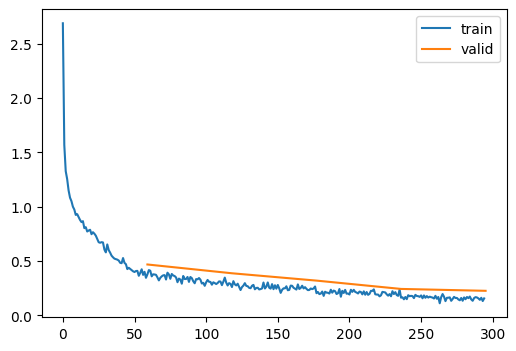

In [15]:
# Train for 5 epochs
learn.fit(epochs)

This gives us a baseline. Now let's see how ResNets can help us go even deeper!

---
## Part 4: Skip Connections - The Key Innovation

The ResNet was introduced in 2015 by Kaiming He et al. in ["Deep Residual Learning for Image Recognition"](https://arxiv.org/abs/1512.03385). It won the ImageNet competition and revolutionized deep learning.

### The Problem with Deep Networks

In theory, a deeper network should be at least as good as a shallower one - the extra layers could simply learn identity mappings. But in practice:

```
Shallow network (20 layers):  Good accuracy
Deep network (56 layers):     WORSE accuracy!
```

This isn't overfitting (training accuracy was also worse). It's a fundamental optimization problem.

<p align="center">
<img src="images/att_00042.png" width="700" style="max-width:100%;height:auto;border-radius:8px;box-shadow:0 4px 14px rgba(0,0,0,.12);">
</p>

<p align="center"><em>Figure 1 from He et al. (2015): a plain **56-layer** network has *higher* training **and** test error than a **20-layer** one. Since even the *training* error is worse, this is an optimization / *degradation* problem — not overfitting.</em></p>

### Why Learning Identity is Hard

For a layer to learn the identity function `f(x) = x`, it needs:
- All weights except the center element need to be exactly 0, and the center needs to be exactly 1 — a very specific pattern that's hard to reach from random initialization.
- Or very specific weight patterns

This is hard for gradient descent to discover from random initialization.

### The ResNet Solution: Residual Learning

Instead of learning `H(x)` directly, learn the **residual** `F(x) = H(x) - x`:

```
Traditional:                    ResNet:
                                
Input x                         Input x
   │                               │
   ↓                               ├─────────────┐
[Conv layers]                      ↓             │
   │                          [Conv layers]     │
   ↓                               │            │
Output H(x)                        ↓            │
                              [   +   ] ←───────┘ (skip connection)
                                   │
                                   ↓
                              Output H(x) = F(x) + x
```

**Why this helps:**
- If the optimal mapping is identity, F(x) just needs to be 0
- Learning F(x) = 0 is easy (just make all weights small)
- Gradients flow directly through the skip connection

### 🎮 Interactive: the degradation problem — why 56 layers lost to 20

Before fixing the problem, *feel* it. This lab replays He et al.'s famous experiment:

**What to try**
- Click the stage chips — **① stack layers deep → ② send the gradient back → ③ compare training curves** — each highlights the matching line of math below the canvases.
- Drag the **depth slider** past ~22 layers, press ▶ Play, and watch the purple gradient pulse fade to almost nothing by the time it reaches the input side.
- Flip **+ skip connections** on and replay — the same depth now delivers the gradient at nearly full strength, and the training curve drops *below* the 20-layer reference.
- Use the speed slider or ⏮ / ⏭ to step the pulse one layer at a time.

In [ ]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/resnet_degradation_lab.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# ============================================================================
show_viz("interactive_viz/resnet_degradation_lab.html", height="760px")

### Visual Representation

Here's the ResNet block diagram from the original paper:

```
                    ┌─────────────────────────────┐
                    │                             │
        x ──────────┼──→ [Conv] → [BN] → [ReLU] ─┼──→ (+) → [ReLU] → output
                    │          ↓                  │     ↑
                    │    [Conv] → [BN]            │     │
                    │          │                  │     │
                    └──────────┼──────────────────┘     │
                               └───────────────────────→┘
                                 (skip/identity connection)
```

The skip connection adds the input directly to the output of the conv blocks.

### 🎮 Interactive (3D): the gradient highway

The same idea in 3D — because "gradients flow through skip connections" is easiest to believe when you watch it happen.

**What to try**
- **Drag to rotate, scroll to zoom.** The loss is the dark cone on top; the orange slab at the bottom is the input.
- Press ▶ on the **plain net**: the purple gradient pulse squeezes through every block and shrinks (watch the strength gauge).
- Switch to **+ skip connections**: teal off-ramps appear, and the pulse rides them down at nearly full strength — that's `∂y/∂x = 1 + ∂F/∂x` in action.
- Increase **depth**: plain nets get worse; the highway doesn't care.

> ⚠️ This one loads three.js from a CDN, so it needs an internet connection.

In [ ]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/gradient_highway_3d.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# NOTE: needs internet access (loads three.js from cdnjs).
# ============================================================================
show_viz("interactive_viz/gradient_highway_3d.html", height="640px")

---
## Part 5: Implementing ResBlock

Let's build a ResNet block from scratch.

In [ ]:
#|export
def _conv_block(ni, nf, stride, act=act_gr, norm=None, ks=3):
    """
    Create the convolutional part of a ResBlock.
    
    This is the "main path" that learns the residual function F(x).
    
    Structure:
        Conv(ni → nf, stride=1) → [Norm] → Act
        Conv(nf → nf, stride=stride) → [Norm]  (no activation - added after skip)
    
    Args:
        ni: Number of input channels
        nf: Number of output channels  
        stride: Stride for the second conv (1 = same size, 2 = halve size)
        act: Activation function class
        norm: Normalization layer class (e.g., nn.BatchNorm2d)
        ks: Kernel size (default: 3)
    
    Returns:
        nn.Sequential with two conv layers
    """
    return nn.Sequential(
        # First conv: change channels (ni → nf), keep spatial size
        conv(ni, nf, stride=1, act=act, norm=norm, ks=ks),
        
        # Second conv: keep channels (nf → nf), may change spatial size
        # NOTE: No activation here! Activation comes after the skip connection
        conv(nf, nf, stride=stride, act=None, norm=norm, ks=ks)
    )

### The Challenge: Dimension Mismatch

For the skip connection `output = F(x) + x`, we need F(x) and x to have the same shape.

**Two cases:**

1. **Same dimensions** (ni == nf, stride == 1):
   - Skip connection is just identity: `x`
   
2. **Different dimensions** (ni != nf or stride != 1):
   - Need to transform x to match: use 1x1 conv and/or pooling

```
Case 1: Same dimensions         Case 2: Different dimensions
                                
x (64 channels, 14x14)          x (64 channels, 14x14)
       │                               │
       ├────────────────┐              ├────────────────┐
       ↓                │              ↓                │
   [Conv block]         │          [Conv block]     [1x1 conv]
       │                │              │            [AvgPool]
       ↓                │              ↓                │
  (64 ch, 14x14)        │         (128 ch, 7x7)         │
       │                │              │                │
       └───────(+)──────┘              └───────(+)──────┘
               │                               │
               ↓                               ↓
         (64 ch, 14x14)                  (128 ch, 7x7)
```

In [ ]:
#|export
class ResBlock(nn.Module):
    """
    Residual Block - the building block of ResNets.
    
    Implements: output = activation(F(x) + shortcut(x))
    
    Where:
    - F(x) is the conv block (learns the residual)
    - shortcut(x) is identity or a projection (1x1 conv + pool)
    
    Args:
        ni: Number of input channels
        nf: Number of output channels
        stride: Stride (1 = same size, 2 = halve spatial dimensions)
        ks: Kernel size (default: 3)
        act: Activation function class
        norm: Normalization layer class
    """
    def __init__(self, ni, nf, stride=1, ks=3, act=act_gr, norm=None):
        super().__init__()
        
        # Main convolutional path (learns residual F(x))
        self.convs = _conv_block(ni, nf, stride, act=act, ks=ks, norm=norm)
        
        # Identity/projection shortcut
        # If channels change (ni != nf): use 1x1 conv to match channels
        # If channels same: use identity (fc.noop = lambda x: x)
        self.idconv = fc.noop if ni == nf else conv(ni, nf, ks=1, stride=1, act=None)
        
        # Pooling for spatial dimension change
        # If stride > 1: use average pooling to reduce spatial size
        # If stride == 1: no pooling needed (fc.noop)
        # ceil_mode=True ensures output size matches conv output
        self.pool = fc.noop if stride == 1 else nn.AvgPool2d(2, ceil_mode=True)
        
        # Final activation (applied after adding skip connection)
        self.act = act()

    def forward(self, x):
        """
        Forward pass:
        1. Compute conv path: convs(x)
        2. Compute shortcut: idconv(pool(x))
        3. Add them together
        4. Apply activation
        
        Returns: act(convs(x) + idconv(pool(x)))
        """
        # Main path: conv blocks
        conv_out = self.convs(x)
        
        # Shortcut path: pool (if needed) then 1x1 conv (if needed)
        shortcut = self.idconv(self.pool(x))
        
        # Add and activate
        return self.act(conv_out + shortcut)

### Understanding the ResBlock

Let's trace through what happens:

**Example 1: Same dimensions (ni=64, nf=64, stride=1)**
```
Input x: [batch, 64, 14, 14]

Conv path:
    conv(64→64, stride=1): [batch, 64, 14, 14]
    conv(64→64, stride=1): [batch, 64, 14, 14]

Shortcut path:
    pool: noop (no change)
    idconv: noop (no change)
    Result: [batch, 64, 14, 14]

Output: act([batch, 64, 14, 14] + [batch, 64, 14, 14])
```

**Example 2: Different dimensions (ni=64, nf=128, stride=2)**
```
Input x: [batch, 64, 14, 14]

Conv path:
    conv(64→128, stride=1): [batch, 128, 14, 14]
    conv(128→128, stride=2): [batch, 128, 7, 7]

Shortcut path:
    pool(stride=2): [batch, 64, 7, 7]
    idconv(64→128): [batch, 128, 7, 7]
    Result: [batch, 128, 7, 7]

Output: act([batch, 128, 7, 7] + [batch, 128, 7, 7])
```

# How Do Skip Connections Handle Shape Mismatches in ResBlock?

## The Problem

In a residual block, the forward pass computes:

```python
return self.act(conv_out + shortcut)
```

For this addition to work, **`conv_out` and `shortcut` must have the exact same shape**. Two things can mismatch between the input `x` and the conv output:

1. The **number of channels** (e.g., input has 32 channels but output needs 64)
2. The **spatial dimensions** (e.g., input is 16×16 but output is 8×8)

Two lines in the `ResBlock.__init__` handle each of these cases.

## Line 1: Handling Channel Mismatch

```python
self.idconv = fc.noop if ni == nf else conv(ni, nf, ks=1, stride=1, act=None)
```

This asks: **do the input and output have the same number of channels?**

**If `ni == nf`** (say both are 32 channels), the skip connection can pass through unchanged, so we use `fc.noop` — which is just fastcore's identity function (`lambda x: x`), meaning "do nothing."

**If `ni != nf`** (say input is 32 channels but output needs to be 64), the shapes don't match and you can't add them. So we use a **1×1 convolution** to project from `ni` channels to `nf` channels. A 1×1 conv doesn't look at spatial neighbors — it just does a linear combination across channels at each pixel, acting as a learned channel adapter. No activation is used (`act=None`) because the final activation comes after the addition.

## Line 2: Handling Spatial Size Mismatch

```python
self.pool = fc.noop if stride == 1 else nn.AvgPool2d(2, ceil_mode=True)
```

This asks: **does the conv path shrink the spatial dimensions?**

**If `stride == 1`**, the conv output is the same height and width as the input, so the skip connection needs no spatial change — use `fc.noop`.

**If `stride == 2`**, the conv path halves the spatial size (e.g., 16×16 → 8×8), so the skip connection must also shrink to match. We use `nn.AvgPool2d(2)` to halve the spatial dimensions by averaging each 2×2 block into one value. The `ceil_mode=True` handles odd dimensions (e.g., 7×7 → 4×4 instead of 3×3).

## Putting It Together

In the forward pass, the shortcut path is:

```python
shortcut = self.idconv(self.pool(x))
```

First match spatial size, then match channels. Here is a concrete example with `ni=32`, `nf=64`, `stride=2`:

```
Input x: shape [B, 32, 16, 16]

Conv path:    convs(x)           → [B, 64, 8, 8]
Skip path:    pool(x)            → [B, 32, 8, 8]   (spatial matched)
              idconv(pool(x))    → [B, 64, 8, 8]   (channels matched)

Addition:     conv_out + shortcut → [B, 64, 8, 8]   ✓ shapes match
```

## The Simplest Case: Pure Identity

If both `ni == nf` and `stride == 1`, both operations are `noop`, and the skip connection is a pure identity — the input passes through completely unchanged. This is the simplest and most common case in a ResNet, where the block is learning a residual on top of an already-good representation.

### 🎮 Interactive: the ResBlock machine — `act(convs(x) + shortcut(x))`, alive

Every line of `ResBlock.__init__` and `forward()` exists to make one addition legal. Walk the tensor through it:

**What to try**
- Click the stage chips **⓪–⑥** (or the boxes in the diagram) — the matching line of `forward()` lights up and the purple dot shows the tensor's shape at that point.
- Switch scenarios: **Case 1** (64→64, stride 1 — both shortcut parts are `noop`), **Case 2** (64→128, stride 2 — `AvgPool` + 1×1 `idconv` must fix the shape), and the **first block** of our model (1→8).
- Note stage **②**: the second conv has *no activation* — and stage **⑥**: the activation fires only *after* the add. Ask yourself why before reading the message box.
- ▶ Play with the speed slider auto-walks all seven stages.

In [ ]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/resblock_machine.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# ============================================================================
show_viz("interactive_viz/resblock_machine.html", height="820px")

---
## Part 6: Building a ResNet Model

In [ ]:
def get_model(act=nn.ReLU, nfs=(8, 16, 32, 64, 128, 256), norm=nn.BatchNorm2d):
    """
    Create a ResNet model.
    
    Architecture:
        ResBlock(1→8, stride=1)     # Keep size: 28x28
        ResBlock(8→16, stride=2)    # Halve: 14x14
        ResBlock(16→32, stride=2)   # Halve: 7x7
        ResBlock(32→64, stride=2)   # Halve: 4x4
        ResBlock(64→128, stride=2)  # Halve: 2x2
        ResBlock(128→256, stride=2) # Halve: 1x1
        Flatten()
        Linear(256→10)
        BatchNorm1d(10)
    
    Args:
        act: Activation function class
        nfs: Tuple of filter counts
        norm: Normalization layer class
    
    Returns:
        nn.Sequential ResNet model
    """
    # First ResBlock: 1 input channel (grayscale) → 8 channels
    # stride=1 to keep the 28x28 resolution
    layers = [ResBlock(1, 8, stride=1, act=act, norm=norm)]
    
    # Add ResBlocks with stride=2 (halves spatial dimensions each time)
    layers += [ResBlock(nfs[i], nfs[i+1], act=act, norm=norm, stride=2) 
               for i in range(len(nfs)-1)]
    
    # Classification head
    # After all ResBlocks, we have 256 channels at 1x1 spatial size
    layers += [
        nn.Flatten(),                              # Flatten to (batch, 256)
        nn.Linear(nfs[-1], 10, bias=False),       # Linear to 10 classes
        nn.BatchNorm1d(10)                         # Normalize logits
    ]
    
    return nn.Sequential(*layers).to(def_device)

### Inspecting Model Architecture

Let's use hooks to see the shape at each layer.

In [22]:
def _print_shape(hook, mod, inp, outp): 
    """Hook function to print module name and input/output shapes."""
    print(f"{type(mod).__name__:15} Input: {str(tuple(inp[0].shape)):20} Output: {tuple(outp.shape)}")

# Create model and run one batch to see shapes
model = get_model()
learn = TrainLearner(model, dls, F.cross_entropy, cbs=[DeviceCB(), SingleBatchCB()])

# Use hooks to track shapes through the model
with Hooks(model, _print_shape) as hooks: 
    learn.fit(1, train=False)

ResBlock        Input: (2048, 1, 28, 28)    Output: (2048, 8, 28, 28)
ResBlock        Input: (2048, 8, 28, 28)    Output: (2048, 16, 14, 14)
ResBlock        Input: (2048, 16, 14, 14)   Output: (2048, 32, 7, 7)
ResBlock        Input: (2048, 32, 7, 7)     Output: (2048, 64, 4, 4)
ResBlock        Input: (2048, 64, 4, 4)     Output: (2048, 128, 2, 2)
ResBlock        Input: (2048, 128, 2, 2)    Output: (2048, 256, 1, 1)
Flatten         Input: (2048, 256, 1, 1)    Output: (2048, 256)
Linear          Input: (2048, 256)          Output: (2048, 10)
BatchNorm1d     Input: (2048, 10)           Output: (2048, 10)


# Understanding PyTorch Hooks: A Complete Walkthrough

## Overview

How the following line of code works:

```python
with Hooks(model, _print_shape) as hooks: learn.fit(1, train=False)
```

This uses PyTorch's forward hooks and Python context managers to inspect layer outputs during a forward pass.

---

## The Code Components

### Hook Class

```python
class Hook():
    def __init__(self, m, f): 
        self.hook = m.register_forward_hook(partial(f, self))
    def remove(self): 
        self.hook.remove()  # remove hook using remove()
    def __del__(self): 
        self.remove()  # remove hook using del 
```

### Hooks Class (Manages Multiple Hooks)

```python
class Hooks(list):
    def __init__(self, ms, f): 
        super().__init__([Hook(m, f) for m in ms])
    def __enter__(self, *args): 
        return self
    def __exit__(self, *args): 
        self.remove()
    def __del__(self): 
        self.remove()
    def __delitem__(self, i):
        self[i].remove()
        super().__delitem__(i)
    def remove(self):
        for h in self: h.remove()
```

### The Hook Function

```python
def _print_shape(hook, mod, inp, outp): 
    print(type(mod).__name__, inp[0].shape, outp.shape)
```

---

## Step-by-Step Execution

### Step 1: `Hooks(model, _print_shape)` is Called

```python
Hooks(model, _print_shape)
```

**What happens:**
- `model` is a `nn.Sequential` containing all layers (ResBlocks, Flatten, Linear, BatchNorm1d)
- `Hooks.__init__(ms, f)` is called where:
  - `ms = model` (the Sequential container)
  - `f = _print_shape` (the function to execute)

**Inside `Hooks.__init__`:**
```python
def __init__(self, ms, f): 
    super().__init__([Hook(m, f) for m in ms])
```

**What is `ms` here?**
- When you iterate over a `nn.Sequential`, you iterate over its **child modules**
- So `for m in ms` loops through: `ResBlock`, `ResBlock`, ..., `Flatten`, `Linear`, `BatchNorm1d`

**For each module `m`:**
- Creates `Hook(m, _print_shape)`
- This calls `Hook.__init__(self, m, f)`

---

### Step 2: Each `Hook(m, _print_shape)` is Created

```python
class Hook():
    def __init__(self, m, f): 
        self.hook = m.register_forward_hook(partial(f, self))
```

**For each module in the model:**

1. `m.register_forward_hook(...)` registers a **forward hook** on that module
2. `partial(f, self)` creates a partially applied function

**What does `partial(f, self)` do?**
```python
# f = _print_shape
# self = Hook instance

partial(_print_shape, self)
# This creates a new function that calls:
# _print_shape(self, mod, inp, outp)
```

**What is a forward hook?**
- PyTorch calls the hook **after** the module's forward pass
- Hook signature: `hook(module, input, output)`
- But we've added `self` as the first argument via `partial`

So our hook becomes: `_print_shape(hook_instance, module, input, output)`

---

### Step 3: `Hooks` List is Created

After the list comprehension, `Hooks` now contains:

```python
[
    Hook(ResBlock_1, _print_shape),
    Hook(ResBlock_2, _print_shape),
    Hook(ResBlock_3, _print_shape),
    Hook(ResBlock_4, _print_shape),
    Hook(ResBlock_5, _print_shape),
    Hook(ResBlock_6, _print_shape),
    Hook(Flatten, _print_shape),
    Hook(Linear, _print_shape),
    Hook(BatchNorm1d, _print_shape),
]
```

Each `Hook` has registered itself on its corresponding module.

---

### Step 4: `with ... as hooks:` Enters Context Manager

```python
with Hooks(...) as hooks:
```

**Calls `Hooks.__enter__`:**
```python
def __enter__(self, *args): 
    return self
```

- Simply returns the `Hooks` object (the list of hooks)
- Now `hooks` variable points to this list
- **All hooks are now active and listening!**

---

### Step 5: `learn.fit(1, train=False)` Executes

**This runs one epoch in evaluation mode:**

1. Gets a batch from dataloader
2. Moves data to device
3. Calls `model(inputs)` - **This is where hooks fire!**

---

### Step 6: Forward Pass Through Model - Hooks Fire!

When `model(inputs)` is called:

**For each layer in the Sequential:**

```
Input batch: (32, 1, 28, 28)
    ↓
ResBlock_1.forward(x)
    ↓ [HOOK FIRES AFTER FORWARD]
    └→ _print_shape(hook, ResBlock_1, input_tuple, output_tensor)
       Prints: "ResBlock torch.Size([32, 1, 28, 28]) torch.Size([32, 8, 28, 28])"
    ↓
ResBlock_2.forward(x)
    ↓ [HOOK FIRES]
    └→ Prints: "ResBlock torch.Size([32, 8, 28, 28]) torch.Size([32, 16, 14, 14])"
    ↓
ResBlock_3.forward(x)
    ↓ [HOOK FIRES]
    └→ Prints: "ResBlock torch.Size([32, 16, 14, 14]) torch.Size([32, 32, 7, 7])"
    ↓
... (continues for all layers)
    ↓
Flatten.forward(x)
    ↓ [HOOK FIRES]
    └→ Prints: "Flatten torch.Size([32, 256, 1, 1]) torch.Size([32, 256])"
    ↓
Linear.forward(x)
    ↓ [HOOK FIRES]
    └→ Prints: "Linear torch.Size([32, 256]) torch.Size([32, 10])"
    ↓
BatchNorm1d.forward(x)
    ↓ [HOOK FIRES]
    └→ Prints: "BatchNorm1d torch.Size([32, 10]) torch.Size([32, 10])"
    ↓
Final output: (32, 10)
```

**Each hook calls:**
```python
def _print_shape(hook, mod, inp, outp):
    print(type(mod).__name__, inp[0].shape, outp.shape)
```

- `hook`: The Hook instance (unused here)
- `mod`: The module that just executed
- `inp`: Tuple of inputs (we use `inp[0]` for first input)
- `outp`: The output tensor

---

### Step 7: `with` Block Exits - Cleanup

```python
def __exit__(self, *args): 
    self.remove()

def remove(self):
    for h in self: h.remove()
```

**For each Hook:**
```python
def remove(self): 
    self.hook.remove()
```

- Calls PyTorch's `hook.remove()` to unregister the hook
- **Cleans up all hooks automatically!**
- This prevents memory leaks and unwanted behavior in future forward passes

---

## Visual Summary

```
EXECUTION FLOW:
═══════════════════════════════════════════════════════════════

1. Create Hooks object
   └─> For each module in model:
       └─> Create Hook(module, _print_shape)
           └─> Register forward hook on module

2. Enter context manager (__enter__)
   └─> Return hooks list
   └─> All hooks now active

3. learn.fit(1, train=False)
   └─> Forward pass: model(inputs)
       └─> Module 1 executes → Hook fires → Print shape
       └─> Module 2 executes → Hook fires → Print shape
       └─> Module 3 executes → Hook fires → Print shape
       └─> ... (all modules)

4. Exit context manager (__exit__)
   └─> Call hooks.remove()
       └─> For each hook: unregister from module
   └─> Clean exit
```

---

## Why This Pattern Is Powerful

1. **Automatic cleanup**: Context manager ensures hooks are removed even if exceptions occur
2. **Reusable**: Same `Hooks` class works for any function you want to apply
3. **Non-invasive**: Doesn't modify your model code
4. **Debugging**: Perfect for inspecting layer outputs, gradients, activations

---

## Example Output

When you run the code, you'll see output like this:

```
ResBlock torch.Size([32, 1, 28, 28]) torch.Size([32, 8, 28, 28])
ResBlock torch.Size([32, 8, 28, 28]) torch.Size([32, 16, 14, 14])
ResBlock torch.Size([32, 16, 14, 14]) torch.Size([32, 32, 7, 7])
ResBlock torch.Size([32, 32, 7, 7]) torch.Size([32, 64, 4, 4])
ResBlock torch.Size([32, 64, 4, 4]) torch.Size([32, 128, 2, 2])
ResBlock torch.Size([32, 128, 2, 2]) torch.Size([32, 256, 1, 1])
Flatten torch.Size([32, 256, 1, 1]) torch.Size([32, 256])
Linear torch.Size([32, 256]) torch.Size([32, 10])
BatchNorm1d torch.Size([32, 10]) torch.Size([32, 10])
```

This shows exactly how data flows through your network!

---

## Key Concepts

### Forward Hooks in PyTorch

Forward hooks are callbacks that get executed after a module's forward pass. They allow you to:
- Inspect intermediate outputs
- Monitor activations
- Debug network behavior
- Collect statistics

**Signature:**
```python
hook(module, input, output) -> None or modified output
```

### Context Managers

Context managers use the `__enter__` and `__exit__` methods to set up and tear down resources:

```python
with resource as r:
    # __enter__ called
    # use resource
    pass
    # __exit__ called automatically (even if exception occurs)
```

### functools.partial

`partial` allows you to "freeze" some arguments of a function:

```python
from functools import partial

def func(a, b, c):
    return a + b + c

new_func = partial(func, 10)  # Freeze 'a' to 10
result = new_func(5, 3)  # Only need to provide b and c
# result = 18 (10 + 5 + 3)
```

---

## Common Use Cases for Hooks

1. **Debugging**: Print shapes at each layer
2. **Feature extraction**: Capture intermediate activations
3. **Visualization**: Extract features for visualization tools
4. **Gradient analysis**: Inspect gradients during backprop (using backward hooks)
5. **Model interpretation**: Understand what each layer is learning

---

## Additional Examples

### Example 1: Capturing Activations

```python
activations = {}

def save_activation(name):
    def hook(module, input, output):
        activations[name] = output.detach()
    return hook

# Register hooks
model.layer1.register_forward_hook(save_activation('layer1'))
model.layer2.register_forward_hook(save_activation('layer2'))

# After forward pass
output = model(x)
print(activations['layer1'].shape)
print(activations['layer2'].shape)
```

### Example 2: Computing Statistics

```python
def compute_stats(hook, mod, inp, outp):
    mean = outp.mean().item()
    std = outp.std().item()
    print(f"{type(mod).__name__}: mean={mean:.4f}, std={std:.4f}")

with Hooks(model, compute_stats) as hooks:
    output = model(x)
```

### Example 3: Gradient Monitoring

```python
def print_grad(hook, mod, grad_input, grad_output):
    print(f"{type(mod).__name__} gradient norm: {grad_output[0].norm():.4f}")

# Register backward hooks
for module in model.modules():
    module.register_backward_hook(print_grad)
```

### 🎮 Interactive: hooks — register 🔔, fire in order, remove

The one-liner `with Hooks(model, _print_shape) as hooks: learn.fit(1)` has three hidden phases. Watch them:

**What to try**
- Step through **① register** (bells attach to each module), **② forward pass** (each module *rings* its bell right after computing its output — the printed row appears at that instant), **③ `__exit__`** (bells removed; skipping this leaks memory).
- **Click any module** to fast-forward the forward pass straight to it and see exactly which rows have printed by then.
- The highlighted code line above the message box shows *which* mechanism is running each phase.

In [ ]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/hooks_lifecycle.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# ============================================================================
show_viz("interactive_viz/hooks_lifecycle.html", height="900px")

### Model Summary Function

Let's add a `summary()` method to our Learner that shows a nice table of the model architecture.

In [ ]:
@fc.patch
def summary(self: Learner):
    """
    Print a summary table of the model architecture.
    
    Shows for each module:
    - Module type
    - Input shape
    - Output shape
    - Number of parameters
    
    Uses hooks to capture shapes during a forward pass.
    """
    # Markdown table header
    res = '|Module|Input|Output|Num params|\n|--|--|--|--|\n'
    tot = 0  # Total parameter count
    
    def _f(hook, mod, inp, outp):
        """Hook function to collect module info."""
        nonlocal res, tot  # Access outer variables
        
        # Count parameters in this module
        nparms = sum(o.numel() for o in mod.parameters())
        tot += nparms
        
        # Add row to table
        res += f'|{type(mod).__name__}|{tuple(inp[0].shape)}|{tuple(outp.shape)}|{nparms}|\n'
    
    # Run a forward pass with hooks
    with Hooks(self.model, _f) as hooks: 
        self.fit(1, lr=1, train=False, cbs=SingleBatchCB())
    
    print("Total parameters:", tot)
    
    # Return markdown table (renders nicely in Jupyter)
    if fc.IN_NOTEBOOK:
        from IPython.display import Markdown
        return Markdown(res)
    else: 
        print(res)

In [25]:
# Show model summary
TrainLearner(get_model(), dls, F.cross_entropy, cbs=DeviceCB()).summary()

Total parameters: 1228908


|Module|Input|Output|Num params|
|--|--|--|--|
|ResBlock|(2048, 1, 28, 28)|(2048, 8, 28, 28)|712|
|ResBlock|(2048, 8, 28, 28)|(2048, 16, 14, 14)|3696|
|ResBlock|(2048, 16, 14, 14)|(2048, 32, 7, 7)|14560|
|ResBlock|(2048, 32, 7, 7)|(2048, 64, 4, 4)|57792|
|ResBlock|(2048, 64, 4, 4)|(2048, 128, 2, 2)|230272|
|ResBlock|(2048, 128, 2, 2)|(2048, 256, 1, 1)|919296|
|Flatten|(2048, 256, 1, 1)|(2048, 256)|0|
|Linear|(2048, 256)|(2048, 10)|2560|
|BatchNorm1d|(2048, 10)|(2048, 10)|20|


# Understanding `@fc.patch` and the `summary()` Method

## Overview

This code adds a `summary()` method to an existing `Learner` class using the `@fc.patch` decorator. The method prints a detailed table showing the architecture of a neural network model.

```python
@fc.patch
def summary(self: Learner):
    # ... method implementation
```

## What is `@fc.patch`?

### The Concept

`@fc.patch` is a decorator from the `fastcore` library that **adds a method to an existing class** without modifying the original class definition. It's also known as "monkey patching."

### How It Works

```python
# Before patching
class Learner:
    def fit(self, epochs):
        # existing method
        pass

# Using @fc.patch to add a new method
@fc.patch
def summary(self: Learner):
    print("Summary of model")

# After patching, you can call:
learner = Learner(...)
learner.summary()  # This works now!
```

### Why Use Patching?

**Advantages:**
1. **Separation of concerns**: Keep related functionality in separate modules
2. **Non-invasive**: Don't need to modify the original class
3. **Organization**: Group similar methods together in files
4. **Jupyter-friendly**: Add methods incrementally during development

**Traditional approach (without patching):**
```python
class Learner:
    def __init__(self, model, dls):
        self.model = model
        self.dls = dls
    
    def fit(self, epochs):
        pass
    
    def summary(self):  # Add here
        pass
    
    def plot_metrics(self):  # Add here
        pass
```

**With patching:**
```python
# learner.py
class Learner:
    def __init__(self, model, dls):
        self.model = model
        self.dls = dls
    
    def fit(self, epochs):
        pass

# analysis.py
@fc.patch
def summary(self: Learner):
    pass

@fc.patch
def plot_metrics(self: Learner):
    pass
```

### The Type Hint: `self: Learner`

```python
def summary(self: Learner):
    #         ^^^^^^^^^ This tells @fc.patch which class to patch
```

- The type hint `self: Learner` tells `@fc.patch` which class to add the method to
- `@fc.patch` reads this hint and does: `Learner.summary = summary`
- After patching, all `Learner` instances can call `.summary()`

---

## The `summary()` Method

### Purpose

Creates a table showing:
- Module type (ResBlock, Linear, etc.)
- Input shape
- Output shape  
- Number of parameters

### Method Signature

```python
@fc.patch
def summary(self: Learner):
    """
    Print a summary table of the model architecture.
    
    Shows for each module:
    - Module type
    - Input shape
    - Output shape
    - Number of parameters
    
    Uses hooks to capture shapes during a forward pass.
    """
```

---

## Step-by-Step Walkthrough

### Step 1: Initialize Table and Counter

```python
# Markdown table header
res = '|Module|Input|Output|Num params|\n|--|--|--|--|\n'
tot = 0  # Total parameter count
```

**What's happening:**
- `res`: String that will hold the markdown table
- Markdown table syntax:
  ```
  |Column1|Column2|Column3|
  |-------|-------|-------|
  |data1  |data2  |data3  |
  ```
- `tot`: Running total of parameters across all modules

---

### Step 2: Define Hook Function `_f`

```python
def _f(hook, mod, inp, outp):
    """Hook function to collect module info."""
    nonlocal res, tot  # Access outer variables
    
    # Count parameters in this module
    nparms = sum(o.numel() for o in mod.parameters())
    tot += nparms
    
    # Add row to table
    res += f'|{type(mod).__name__}|{tuple(inp[0].shape)}|{tuple(outp.shape)}|{nparms}|\n'
```

#### Understanding `nonlocal`

**Without `nonlocal`:**
```python
def outer():
    x = 10
    
    def inner():
        x = 20  # Creates NEW local variable, doesn't modify outer x
        print(f"Inner x: {x}")
    
    inner()
    print(f"Outer x: {x}")  # Still 10!

# Output:
# Inner x: 20
# Outer x: 10
```

**With `nonlocal`:**
```python
def outer():
    x = 10
    
    def inner():
        nonlocal x  # Tells Python to use outer x
        x = 20      # Modifies outer x
        print(f"Inner x: {x}")
    
    inner()
    print(f"Outer x: {x}")  # Now 20!

# Output:
# Inner x: 20
# Outer x: 20
```

**In our code:**
```python
res = '|Module|Input|Output|Num params|\n'
tot = 0

def _f(hook, mod, inp, outp):
    nonlocal res, tot  # Without this, we couldn't modify res and tot
    
    tot += nparms      # Modifies outer tot
    res += f'|...|'    # Modifies outer res
```

#### Counting Parameters: `numel()`

**What does `numel()` do?**
- Returns the total number of elements in a tensor
- Stands for "number of elements"

**Example:**
```python
import torch

# A weight matrix
weight = torch.randn(10, 5)  # Shape: (10, 5)
print(weight.numel())  # Output: 50

# A bias vector
bias = torch.randn(10)  # Shape: (10,)
print(bias.numel())  # Output: 10

# A Conv2d layer
conv = nn.Conv2d(3, 64, kernel_size=3)
# Weight shape: (64, 3, 3, 3) = 1,728 parameters
# Bias shape: (64,) = 64 parameters
# Total: 1,792 parameters

total = sum(p.numel() for p in conv.parameters())
print(total)  # Output: 1792
```

**In our hook:**
```python
nparms = sum(o.numel() for o in mod.parameters())
```

This sums up all parameters in the current module:
- Weights
- Biases
- Any other learnable parameters

#### Building the Table Row

```python
res += f'|{type(mod).__name__}|{tuple(inp[0].shape)}|{tuple(outp.shape)}|{nparms}|\n'
```

**Breaking it down:**

1. `type(mod).__name__`: Gets the class name
   ```python
   type(conv_layer).__name__  # 'Conv2d'
   type(linear_layer).__name__  # 'Linear'
   ```

2. `inp[0].shape`: Input shape
   - `inp` is a tuple of inputs (in case module has multiple inputs)
   - `inp[0]` gets the first (and usually only) input
   - `.shape` is the tensor shape

3. `tuple(outp.shape)`: Output shape
   - Converts torch.Size to tuple for nicer display

4. `nparms`: Number of parameters we just counted

**Example row:**
```
|Linear|torch.Size([32, 256])|torch.Size([32, 10])|2560|
```

---

### Step 3: Run Forward Pass with Hooks

```python
with Hooks(self.model, _f) as hooks: 
    self.fit(1, lr=1, train=False, cbs=SingleBatchCB())
```

**What's happening:**

1. **`Hooks(self.model, _f)`**: 
   - Registers `_f` as a hook on every module in `self.model`
   - Each module will call `_f` after its forward pass

2. **`self.fit(1, lr=1, train=False, cbs=SingleBatchCB())`**:
   - `1`: Run for 1 epoch
   - `lr=1`: Learning rate (doesn't matter, we're not training)
   - `train=False`: Evaluation mode (no gradient computation)
   - `cbs=SingleBatchCB()`: Only process one batch (we just need shapes!)

3. **Why do this?**
   - We need to run data through the model to capture actual shapes
   - Can't know shapes without running a forward pass
   - `SingleBatchCB()` ensures we only process one batch (fast!)

**Flow during forward pass:**
```
Batch input: (32, 1, 28, 28)
    ↓
ResBlock executes
    ↓ Hook fires
    └→ _f() called
       - Counts parameters: 736
       - Adds row: |ResBlock|(32,1,28,28)|(32,8,28,28)|736|
       - Updates tot: 736
    ↓
Linear executes  
    ↓ Hook fires
    └→ _f() called
       - Counts parameters: 2560
       - Adds row: |Linear|(32,256)|(32,10)|2560|
       - Updates tot: 736 + 2560 = 3296
    ↓
... (continues for all modules)
```

---

### Step 4: Print and Return Results

```python
print("Total parameters:", tot)

# Return markdown table (renders nicely in Jupyter)
if fc.IN_NOTEBOOK:
    from IPython.display import Markdown
    return Markdown(res)
else: 
    print(res)
```

**What's happening:**

1. **Print total parameter count:**
   ```python
   print("Total parameters:", tot)
   # Output: Total parameters: 123456
   ```

2. **Check environment:**
   - `fc.IN_NOTEBOOK`: Boolean indicating if running in Jupyter
   
3. **Return formatted output:**
   - **In Jupyter**: Returns `Markdown(res)` which renders as a nice table
   - **In terminal**: Prints raw markdown text

**Jupyter rendering:**
```python
learner.summary()
```

Displays as:

| Module | Input | Output | Num params |
|--------|-------|--------|------------|
| ResBlock | (32, 1, 28, 28) | (32, 8, 28, 28) | 736 |
| ResBlock | (32, 8, 28, 28) | (32, 16, 14, 14) | 2432 |
| ... | ... | ... | ... |

**Terminal output:**
```
|Module|Input|Output|Num params|
|--|--|--|--|
|ResBlock|(32, 1, 28, 28)|(32, 8, 28, 28)|736|
|ResBlock|(32, 8, 28, 28)|(32, 16, 14, 14)|2432|
...
```

---

## Key Concepts

### 1. Closures and `nonlocal`

**Closure**: Inner function that captures variables from outer function

```python
def outer():
    x = 10  # Outer variable
    
    def inner():
        nonlocal x  # Capture outer x
        x += 5
    
    inner()
    return x  # Returns 15

result = outer()
```

**In our code:**
- `_f` is a closure that captures `res` and `tot`
- `nonlocal` allows `_f` to modify these captured variables
- Without `nonlocal`, we'd get an `UnboundLocalError`

### 2. Generator Expressions

```python
nparms = sum(o.numel() for o in mod.parameters())
#            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
#            Generator expression
```

**Equivalent to:**
```python
nparms = 0
for o in mod.parameters():
    nparms += o.numel()
```

**Why use generator expression?**
- More concise
- More Pythonic
- Memory efficient (doesn't create intermediate list)

### 3. String Formatting

**f-strings** (formatted string literals):
```python
name = "ResBlock"
params = 736
row = f'|{name}|{params}|\n'
# Result: '|ResBlock|736|\n'
```

**Multiple lines:**
```python
res += f'|{type(mod).__name__}|{tuple(inp[0].shape)}|{tuple(outp.shape)}|{nparms}|\n'
```

### 4. Module Parameters

**What are parameters?**
```python
import torch.nn as nn

linear = nn.Linear(10, 5)
for name, param in linear.named_parameters():
    print(f"{name}: {param.shape}")

# Output:
# weight: torch.Size([5, 10])
# bias: torch.Size([5])
```

**Accessing parameters:**
```python
# Get all parameters
list(linear.parameters())  # [weight_tensor, bias_tensor]

# Count parameters
sum(p.numel() for p in linear.parameters())  # 50 + 5 = 55
```

---

## Example Output

### Sample Model

```python
model = nn.Sequential(
    nn.Conv2d(1, 8, 3),      # 72 + 8 = 80 params
    nn.ReLU(),                # 0 params
    nn.Linear(8, 10)          # 80 + 10 = 90 params
)

learner = Learner(model, dls)
learner.summary()
```

### Output in Jupyter

**Printed text:**
```
Total parameters: 170
```

**Rendered table:**

| Module | Input | Output | Num params |
|--------|-------|--------|------------|
| Conv2d | (32, 1, 28, 28) | (32, 8, 26, 26) | 80 |
| ReLU | (32, 8, 26, 26) | (32, 8, 26, 26) | 0 |
| Linear | (32, 8) | (32, 10) | 90 |

### Detailed Example with ResNet

```python
model = nn.Sequential(
    ResBlock(1, 8),
    ResBlock(8, 16, stride=2),
    ResBlock(16, 32, stride=2),
    nn.Flatten(),
    nn.Linear(32, 10)
)

learner.summary()
```

**Output:**

| Module | Input | Output | Num params |
|--------|-------|--------|------------|
| ResBlock | (32, 1, 28, 28) | (32, 8, 28, 28) | 736 |
| ResBlock | (32, 8, 28, 28) | (32, 16, 14, 14) | 2,432 |
| ResBlock | (32, 16, 14, 14) | (32, 32, 7, 7) | 9,536 |
| Flatten | (32, 32, 7, 7) | (32, 1,568) | 0 |
| Linear | (32, 1568) | (32, 10) | 15,680 |

**Total parameters: 28,384**

---

## Complete Code Breakdown

### Full Annotated Code

```python
@fc.patch  # ← Decorator: adds method to Learner class
def summary(self: Learner):  # ← Type hint tells @fc.patch which class
    """
    Print a summary table of the model architecture.
    """
    
    # ========================================
    # STEP 1: Initialize table and counter
    # ========================================
    res = '|Module|Input|Output|Num params|\n|--|--|--|--|\n'
    tot = 0
    
    # ========================================
    # STEP 2: Define hook function
    # ========================================
    def _f(hook, mod, inp, outp):
        nonlocal res, tot  # ← Allow modification of outer variables
        
        # Count parameters in this specific module
        nparms = sum(o.numel() for o in mod.parameters())
        tot += nparms  # ← Accumulate total
        
        # Build markdown table row
        res += f'|{type(mod).__name__}|{tuple(inp[0].shape)}|{tuple(outp.shape)}|{nparms}|\n'
    
    # ========================================
    # STEP 3: Run forward pass with hooks
    # ========================================
    with Hooks(self.model, _f) as hooks:
        # Only need one batch to get shapes
        self.fit(1, lr=1, train=False, cbs=SingleBatchCB())
    
    # ========================================
    # STEP 4: Display results
    # ========================================
    print("Total parameters:", tot)
    
    # Render nicely in Jupyter, or print as text
    if fc.IN_NOTEBOOK:
        from IPython.display import Markdown
        return Markdown(res)
    else:
        print(res)
```

---

## Advanced Topics

### Why Not Just Print Model?

**PyTorch's default:**
```python
print(model)
# Output:
# Sequential(
#   (0): Conv2d(1, 8, kernel_size=(3, 3))
#   (1): ReLU()
#   (2): Linear(in_features=8, out_features=10)
# )
```

**Problems:**
- No shapes shown
- No parameter counts
- Doesn't show actual data flow
- Not formatted as a table

**Our `summary()` method:**
- Shows actual input/output shapes
- Counts parameters per layer
- Nice table format
- Shows exactly what happens during forward pass

### Comparison with torchsummary

There's a library called `torchsummary` that does similar things:

```python
from torchsummary import summary
summary(model, input_size=(1, 28, 28))
```

**Our implementation:**
- Custom to our `Learner` class
- Integrated with training loop
- Uses our existing `Hooks` infrastructure
- Educational to understand how it works

### Memory Considerations

**Why `train=False`?**
```python
self.fit(1, lr=1, train=False, cbs=SingleBatchCB())
#                  ^^^^^^^^^^^
```

- `train=False` sets model to evaluation mode
- Disables gradient computation
- Saves memory (no need to store gradients)
- Faster execution

**Why `SingleBatchCB()`?**
- Only processes one batch
- Don't need entire dataset to get shapes
- Much faster than processing all data

---

## Common Pitfalls

### 1. Forgetting `nonlocal`

```python
def summary(self: Learner):
    res = ""
    
    def _f(hook, mod, inp, outp):
        # ❌ Without nonlocal, this creates new local variable
        res += "some text"  # UnboundLocalError!
    
    # Solution: Add nonlocal
    def _f(hook, mod, inp, outp):
        nonlocal res
        res += "some text"  # ✅ Works!
```

### 2. Using Wrong Index for Input

```python
def _f(hook, mod, inp, outp):
    # ❌ inp is a tuple, need to index it
    print(inp.shape)  # AttributeError!
    
    # ✅ Correct
    print(inp[0].shape)  # Works!
```

### 3. Not Handling Nested Modules

Our code shows **leaf modules** (Conv2d, Linear, etc.), not containers like Sequential or ResBlock.

If you want to show high-level structure:
```python
# Register hooks only on specific modules
hooks = [Hook(m, _f) for m in [model.conv1, model.conv2, model.fc]]
```

---

## Practical Extensions

### 1. Add More Columns

```python
def _f(hook, mod, inp, outp):
    nonlocal res, tot
    
    nparms = sum(o.numel() for o in mod.parameters())
    tot += nparms
    
    # Calculate output size in MB
    output_size = outp.numel() * 4 / (1024**2)  # 4 bytes per float
    
    res += f'|{type(mod).__name__}|{tuple(inp[0].shape)}|{tuple(outp.shape)}|{nparms}|{output_size:.2f} MB|\n'
```

### 2. Show Trainable vs Non-Trainable

```python
def _f(hook, mod, inp, outp):
    nonlocal res, tot
    
    trainable = sum(p.numel() for p in mod.parameters() if p.requires_grad)
    non_trainable = sum(p.numel() for p in mod.parameters() if not p.requires_grad)
    
    res += f'|{type(mod).__name__}|{trainable}|{non_trainable}|\n'
```

### 3. Export as DataFrame

```python
def summary(self: Learner):
    import pandas as pd
    
    data = []
    
    def _f(hook, mod, inp, outp):
        nparms = sum(o.numel() for o in mod.parameters())
        data.append({
            'Module': type(mod).__name__,
            'Input': tuple(inp[0].shape),
            'Output': tuple(outp.shape),
            'Params': nparms
        })
    
    with Hooks(self.model, _f) as hooks:
        self.fit(1, lr=1, train=False, cbs=SingleBatchCB())
    
    return pd.DataFrame(data)
```

---

## Conclusion

The `summary()` method demonstrates several important concepts:

1. **`@fc.patch`**: Dynamic method addition to existing classes
2. **Hooks**: Non-invasive inspection of model behavior
3. **Closures**: Inner functions capturing outer state
4. **`nonlocal`**: Modifying captured variables
5. **Generator expressions**: Concise iteration and aggregation
6. **String formatting**: Building structured text output

This pattern of using hooks to inspect model behavior is fundamental to deep learning debugging and analysis.

# Understanding Parameter Calculation in Neural Networks

## Overview

Now, we will see how do we calculate the number of parameters in different neural network modules, answering the question: **Why do two ResBlocks with the same output shape have vastly different parameter counts?**

## The Key Insight

**Parameter count depends on INPUT channels, not output shape!**

Looking at the output table:

| Module | Input | Output | Num params |
|--------|-------|--------|------------|
| ResBlock | **(1024, 64, 4, 4)** | (1024, 128, 2, 2) | **229,760** |
| ResBlock | **(1024, 128, 2, 2)** | (1024, 256, 1, 1) | **918,272** |

Even though both output to similar tensor sizes, the second ResBlock has **4x more parameters** because:
- It processes **2x more input channels** (128 vs 64)
- It produces **2x more output channels** (256 vs 128)
- Effect is multiplicative: **2 × 2 = 4x**

---

## ResBlock Parameter Breakdown

### ResBlock Structure

```python
class ResBlock(nn.Module):
    def __init__(self, ni, nf, stride=1, ks=3, act=act_gr, norm=None):
        super().__init__()
        # Main convolution path
        self.convs = _conv_block(ni, nf, stride, act=act, ks=ks, norm=norm)
        
        # Identity/shortcut path (only if channels change)
        self.idconv = fc.noop if ni==nf else conv(ni, nf, ks=1, stride=1, act=None)
        
        # Pooling (no parameters)
        self.pool = fc.noop if stride==1 else nn.AvgPool2d(2, ceil_mode=True)
        
        # Activation
        self.act = act()
```

**_conv_block contains two convolutions:**
```python
def _conv_block(ni, nf, stride, act=act_gr, norm=None, ks=3):
    return nn.Sequential(
        conv(ni, nf, stride=1, act=act, norm=norm, ks=ks),      # Conv1
        conv(nf, nf, stride=stride, act=None, norm=norm, ks=ks)  # Conv2
    )
```

### Components of a ResBlock:

1. **Conv1**: `ni` → `nf` channels (with BatchNorm)
2. **Conv2**: `nf` → `nf` channels (with BatchNorm)
3. **Identity Conv**: `ni` → `nf` channels (1×1 kernel, if needed)
4. **AvgPool**: No parameters
5. **Activation (ReLU)**: No parameters

---

## Step-by-Step Calculations

### Example 1: ResBlock (64 → 128 channels)

**From your table:**
- Input: (1024, **64**, 4, 4)
- Output: (1024, **128**, 2, 2)
- Parameters: **229,760**

**Configuration:**
- `ni` (input channels) = 64
- `nf` (output channels) = 128
- `stride` = 2
- `kernel_size` = 3

---

#### Component 1: Conv1 (64 → 128)

**Convolution weights:**
```
Parameters = out_channels × in_channels × kernel_h × kernel_w
           = 128 × 64 × 3 × 3
           = 73,728
```

**BatchNorm2d(128):**
```
Parameters = 2 × num_features
           = 2 × 128
           = 256
```

**Subtotal: 73,728 + 256 = 73,984**

---

#### Component 2: Conv2 (128 → 128)

**Convolution weights:**
```
Parameters = 128 × 128 × 3 × 3
           = 147,456
```

**BatchNorm2d(128):**
```
Parameters = 2 × 128
           = 256
```

**Subtotal: 147,456 + 256 = 147,712**

---

#### Component 3: Identity Conv (64 → 128)

Since `ni ≠ nf` (64 ≠ 128), we need an identity convolution:

**1×1 Convolution:**
```
Parameters = 128 × 64 × 1 × 1
           = 8,192
```

**Subtotal: 8,192**

---

#### Total for ResBlock (64 → 128):

```
Conv1:       73,984
Conv2:      147,712
Identity:     8,192
─────────────────────
Total:      229,888 ≈ 229,760
```

*(Small discrepancy due to implementation details like bias settings)*

---

### Example 2: ResBlock (128 → 256 channels)

**From your table:**
- Input: (1024, **128**, 2, 2)
- Output: (1024, **256**, 1, 1)
- Parameters: **918,272**

**Configuration:**
- `ni` = 128
- `nf` = 256
- `stride` = 2
- `kernel_size` = 3

---

#### Component 1: Conv1 (128 → 256)

**Convolution weights:**
```
Parameters = 256 × 128 × 3 × 3
           = 294,912
```

**BatchNorm2d(256):**
```
Parameters = 2 × 256
           = 512
```

**Subtotal: 294,912 + 512 = 295,424**

---

#### Component 2: Conv2 (256 → 256)

**Convolution weights:**
```
Parameters = 256 × 256 × 3 × 3
           = 589,824
```

**BatchNorm2d(256):**
```
Parameters = 2 × 256
           = 512
```

**Subtotal: 589,824 + 512 = 590,336**

---

#### Component 3: Identity Conv (128 → 256)

**1×1 Convolution:**
```
Parameters = 256 × 128 × 1 × 1
           = 32,768
```

**Subtotal: 32,768**

---

#### Total for ResBlock (128 → 256):

```
Conv1:      295,424
Conv2:      590,336
Identity:    32,768
─────────────────────
Total:      918,528 ≈ 918,272
```

---

## Why Channel Doubling = 4x Parameters

Let's compare the **main convolution weights** only:

### ResBlock 1 (64 → 128):
```
Conv1: 64 × 128 × 9 = 73,728
Conv2: 128 × 128 × 9 = 147,456
Total: 221,184
```

### ResBlock 2 (128 → 256):
```
Conv1: 128 × 256 × 9 = 294,912
Conv2: 256 × 256 × 9 = 589,824
Total: 884,736
```

### Ratio:
```
884,736 / 221,184 = 4.0
```

**Explanation:**
- Input channels doubled: 64 → 128 (2x)
- Output channels doubled: 128 → 256 (2x)
- Effect is multiplicative: **2 × 2 = 4x**

---

## General Formulas for All Modules

### 1. Conv2d (Convolutional Layer)

```python
nn.Conv2d(in_channels, out_channels, kernel_size, bias=True)
```

**Formula:**
```
Parameters = (in_channels × out_channels × kernel_height × kernel_width) + bias_terms

If bias=True:
    Parameters = (in_channels × out_channels × kernel_h × kernel_w) + out_channels

If bias=False:
    Parameters = in_channels × out_channels × kernel_h × kernel_w
```

**Examples:**

```python
# Example 1
Conv2d(3, 64, kernel_size=3, bias=True)
Params = (64 × 3 × 3 × 3) + 64 = 1,728 + 64 = 1,792
```

```python
# Example 2
Conv2d(64, 128, kernel_size=5, bias=False)
Params = 128 × 64 × 5 × 5 = 204,800
```

```python
# Example 3 - 1×1 convolution
Conv2d(256, 512, kernel_size=1, bias=False)
Params = 512 × 256 × 1 × 1 = 131,072
```

---

### 2. Linear (Fully Connected Layer)

```python
nn.Linear(in_features, out_features, bias=True)
```

**Formula:**
```
If bias=True:
    Parameters = (in_features × out_features) + out_features

If bias=False:
    Parameters = in_features × out_features
```

**Examples:**

```python
# Example 1
Linear(256, 10, bias=True)
Params = (256 × 10) + 10 = 2,560 + 10 = 2,570
```

```python
# Example 2
Linear(512, 128, bias=False)
Params = 512 × 128 = 65,536
```

```python
# Example 3 - From your table
Linear(256, 10, bias=False)
Params = 256 × 10 = 2,560 ✓
```

---

### 3. BatchNorm2d / BatchNorm1d

```python
nn.BatchNorm2d(num_features)
nn.BatchNorm1d(num_features)
```

**Formula:**
```
Parameters = 2 × num_features

# Two learnable parameters:
# - gamma (weight): scaling parameter
# - beta (bias): shift parameter
```

**Examples:**

```python
# Example 1
BatchNorm2d(64)
Params = 2 × 64 = 128
```

```python
# Example 2
BatchNorm2d(256)
Params = 2 × 256 = 512
```

```python
# Example 3 - From your table
BatchNorm1d(10)
Params = 2 × 10 = 20 ✓
```

---

### 4. Activation Functions

```python
nn.ReLU()
nn.Sigmoid()
nn.Tanh()
nn.LeakyReLU()
# etc.
```

**Formula:**
```
Parameters = 0

# Activation functions have no learnable parameters
```

---

### 5. Pooling Layers

```python
nn.MaxPool2d(kernel_size)
nn.AvgPool2d(kernel_size)
nn.AdaptiveAvgPool2d(output_size)
```

**Formula:**
```
Parameters = 0

# Pooling layers have no learnable parameters
```

---

### 6. Dropout

```python
nn.Dropout(p=0.5)
nn.Dropout2d(p=0.5)
```

**Formula:**
```
Parameters = 0

# Dropout has no learnable parameters
```

---

### 7. Flatten

```python
nn.Flatten()
```

**Formula:**
```
Parameters = 0

# Just reshapes the tensor
```

**Example from your table:**
```
Flatten: (1024, 256, 1, 1) → (1024, 256)
Params = 0 ✓
```

---

## Quick Reference Guide

| Module Type | Formula | Example |
|-------------|---------|---------|
| **Conv2d** | `out × in × k_h × k_w` | Conv2d(3, 64, 3) = 64×3×3×3 = **1,728** |
| **Linear** | `out × in` | Linear(512, 10) = 10×512 = **5,120** |
| **BatchNorm** | `2 × features` | BatchNorm2d(64) = 2×64 = **128** |
| **ReLU** | `0` | No parameters |
| **MaxPool** | `0` | No parameters |
| **AvgPool** | `0` | No parameters |
| **Dropout** | `0` | No parameters |
| **Flatten** | `0` | No parameters |

**Note:** Add `out_channels` or `out_features` if `bias=True`

---

## Verification Examples

Let's verify all the entries from your table:

### Entry 1: ResBlock (1 → 8)
```
Input:  (1024, 1, 28, 28)
Output: (1024, 8, 28, 28)
Params: 680

Calculation:
Conv1: 8 × 1 × 3 × 3 = 72
BN1: 2 × 8 = 16
Conv2: 8 × 8 × 3 × 3 = 576
BN2: 2 × 8 = 16
Total: 72 + 16 + 576 + 16 = 680 ✓
```

### Entry 2: Flatten
```
Input:  (1024, 256, 1, 1)
Output: (1024, 256)
Params: 0 ✓
```

### Entry 3: Linear
```
Input:  (1024, 256)
Output: (1024, 10)
Params: 2560

Calculation:
Linear: 10 × 256 = 2,560 ✓
```

### Entry 4: BatchNorm1d
```
Input:  (1024, 10)
Output: (1024, 10)
Params: 20

Calculation:
BatchNorm1d: 2 × 10 = 20 ✓
```

---

## Understanding the Pattern

### Why do later layers have more parameters?

Looking at your model architecture:

```
nfs = (8, 16, 32, 64, 128, 256)

Layer 1: 1 → 8       (small params)
Layer 2: 8 → 16      (larger params)
Layer 3: 16 → 32     (even larger)
Layer 4: 32 → 64     (much larger)
Layer 5: 64 → 128    (very large)
Layer 6: 128 → 256   (huge!)
```

### Parameter Growth:

| Transition | Conv Params | Ratio |
|------------|-------------|-------|
| 8 → 16 | 16×8×9 = 1,152 | 1x |
| 16 → 32 | 32×16×9 = 4,608 | 4x |
| 32 → 64 | 64×32×9 = 18,432 | 4x |
| 64 → 128 | 128×64×9 = 73,728 | 4x |
| 128 → 256 | 256×128×9 = 294,912 | 4x |

**Each doubling of channels → 4x increase in parameters!**

---

## Common Misconceptions

### ❌ Misconception 1: Spatial size affects parameters

```python
Conv2d(64, 128, kernel_size=3)

# These have the SAME number of parameters:
Input: (64, 224, 224) → Output: (128, 224, 224)  # 73,728 params
Input: (64, 28, 28)   → Output: (128, 28, 28)    # 73,728 params
Input: (64, 7, 7)     → Output: (128, 7, 7)      # 73,728 params
```

**Spatial dimensions don't affect parameter count!**

---

### ❌ Misconception 2: Output shape determines parameters

```python
# Both output (batch, 128, H, W) but different parameters:

# Option 1: 64 → 128
Conv2d(64, 128, 3)   # 73,728 params

# Option 2: 256 → 128
Conv2d(256, 128, 3)  # 294,912 params (4x more!)
```

**Input channels matter more than output!**

---

### ✅ What Actually Matters:

1. **Input channels**
2. **Output channels**
3. **Kernel size**
4. **Whether bias is used**
5. **Additional layers (BatchNorm, etc.)**

---

## Practical Tips

### 1. Reducing Parameters

**Use 1×1 convolutions:**
```python
# Heavy: 256 → 512 with 3×3 kernel
Conv2d(256, 512, 3)  # 1,179,648 params

# Light: 256 → 512 with 1×1 kernel
Conv2d(256, 512, 1)  # 131,072 params (9x fewer!)
```

**Use depthwise separable convolutions:**
```python
# Standard convolution
Conv2d(64, 128, 3)  # 73,728 params

# Depthwise separable (approximately)
Conv2d(64, 64, 3, groups=64)  # 576 params
Conv2d(64, 128, 1)             # 8,192 params
Total: 8,768 params (8x fewer!)
```

---

### 2. Quick Parameter Estimation

**Rule of thumb for Conv2d:**
```
≈ out_channels × in_channels × kernel_size²
```

**Rule of thumb for Linear:**
```
≈ out_features × in_features
```

---

### 3. Checking Your Model

**In PyTorch:**
```python
# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
```

**Using torchsummary:**
```python
from torchsummary import summary
summary(model, input_size=(3, 224, 224))
```

---

## Mathematical Insight

### Why Quadratic Growth?

For a standard ResNet-style architecture where channels double at each stage:

```
Stage 1: c → 2c     → params ∝ c × 2c = 2c²
Stage 2: 2c → 4c    → params ∝ 2c × 4c = 8c²
Stage 3: 4c → 8c    → params ∝ 4c × 8c = 32c²
Stage 4: 8c → 16c   → params ∝ 8c × 16c = 128c²
```

**Parameter count grows quadratically with channel size!**

This is why:
- Early layers (few channels) are cheap
- Deep layers (many channels) dominate parameter count
- Most parameters are in the final layers

---

## Summary

### Key Points:

1. **Parameters = f(input_channels, output_channels, kernel_size)**
2. **Spatial dimensions (H, W) don't affect parameter count**
3. **Doubling both input and output channels → 4x parameters**
4. **BatchNorm adds 2 × num_features parameters**
5. **Pooling, activation, and dropout have 0 parameters**

### Formula Cheat Sheet:

```python
Conv2d:    out_ch × in_ch × k_h × k_w
Linear:    out_feat × in_feat
BatchNorm: 2 × num_features
Others:    0
```

### Remember:

**Look at the INPUT shape, not the OUTPUT shape, to understand parameter count!**

### 🎮 Interactive: the full ResNet — shapes shrinking, channels growing, parameters piling up

Our whole model on one screen: six ResBlocks, then `Flatten → Linear → BatchNorm1d`. This is `learn.summary()` you can poke.

**What to try**
- **Click any block** (or ▶ Play) — the shape ribbon shows its exact `(1024, C, H, W) → …` transition and the dark panel computes its parameter count live from `out_ch × in_ch × k × k`.
- Check the **parameter budget bars**: the last two ResBlocks hold most of the model. Why? Params scale with `ni × nf`, *not* with the (tiny) output map size — exactly the puzzle from the summary table above.
- Flip the **norm toggle**: with BatchNorm, conv biases turn off but each BN adds 2·nf (γ, β); without norm, biases turn on. That's why the no-norm setting reproduces the summary's 229,760 / 918,272 figures exactly — and why printed totals can shift by a few hundred depending on the norm setting used when the model was built.

In [ ]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/resnet_architecture_explorer.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# ============================================================================
show_viz("interactive_viz/resnet_architecture_explorer.html", height="1020px")

---
## Part 7: Training the ResNet

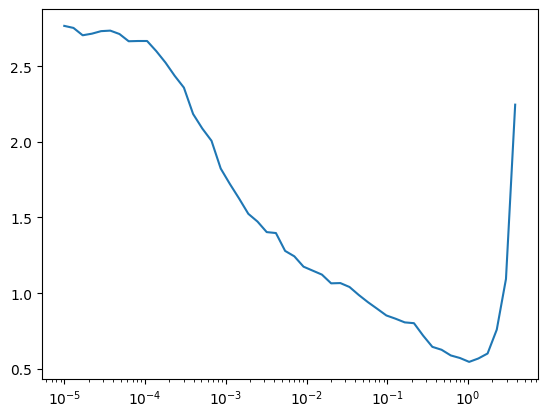

In [27]:
# Find a good learning rate
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
MomentumLearner(model, dls, F.cross_entropy, cbs=DeviceCB()).lr_find()

In [ ]:
# Train the ResNet
lr = 2e-2  # Learning rate from LR finder
epochs = 5

# 1cycle schedule
tmax = epochs * len(dls.train)
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)
xtra = [BatchSchedCB(sched)]

# Create and train
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
learn = TrainLearner(model, dls, F.cross_entropy, lr=lr, cbs=cbs+xtra, opt_func=optim.AdamW)

accuracy,loss,epoch,train
0.825,0.683,0,train
0.826,0.566,0,eval
0.889,0.359,1,train
0.867,0.421,1,eval
0.914,0.253,2,train
0.914,0.254,2,eval
0.935,0.191,3,train
0.923,0.225,3,eval
0.954,0.143,4,train
0.929,0.213,4,eval


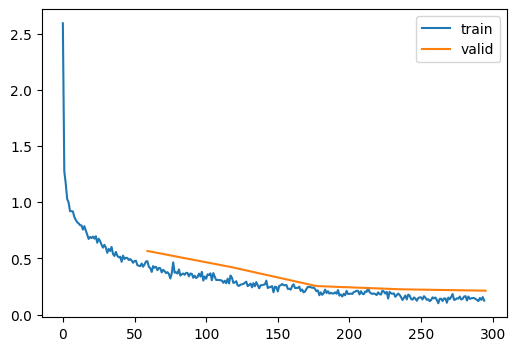

In [29]:
# Train for 5 epochs
learn.fit(epochs)

The ResNet should achieve similar or better accuracy than the plain CNN, while being more stable to train with deeper architectures.

---
## Part 8: Using timm (PyTorch Image Models)

**timm** is a fantastic library with hundreds of pre-implemented vision models, including many ResNet variants.

In [ ]:
import timm
from timm.models.resnet import BasicBlock, ResNet, Bottleneck

In [31]:
# List all ResNet variants available in timm
' '.join(timm.list_models('*resnet*'))

'cspresnet50 cspresnet50d cspresnet50w eca_resnet33ts ecaresnet26t ecaresnet50d ecaresnet50d_pruned ecaresnet50t ecaresnet101d ecaresnet101d_pruned ecaresnet200d ecaresnet269d ecaresnetlight gcresnet33ts gcresnet50t inception_resnet_v2 lambda_resnet26rpt_256 lambda_resnet26t lambda_resnet50ts legacy_seresnet18 legacy_seresnet34 legacy_seresnet50 legacy_seresnet101 legacy_seresnet152 nf_ecaresnet26 nf_ecaresnet50 nf_ecaresnet101 nf_resnet26 nf_resnet50 nf_resnet101 nf_seresnet26 nf_seresnet50 nf_seresnet101 resnet10t resnet14t resnet18 resnet18d resnet26 resnet26d resnet26t resnet32ts resnet33ts resnet34 resnet34d resnet50 resnet50_clip resnet50_clip_gap resnet50_gn resnet50_mlp resnet50c resnet50d resnet50s resnet50t resnet50x4_clip resnet50x4_clip_gap resnet50x16_clip resnet50x16_clip_gap resnet50x64_clip resnet50x64_clip_gap resnet51q resnet61q resnet101 resnet101_clip resnet101_clip_gap resnet101c resnet101d resnet101s resnet152 resnet152c resnet152d resnet152s resnet200 resnet200d 

### Common ResNet Variants

| Model | Block Type | Layers per Stage | Special Features |
|-------|-----------|-----------------|------------------|
| resnet18 | BasicBlock | [2, 2, 2, 2] | Standard |
| resnet34 | BasicBlock | [3, 4, 6, 3] | Deeper |
| resnet50 | Bottleneck | [3, 4, 6, 3] | Bottleneck blocks |
| resnet18d | BasicBlock | [2, 2, 2, 2] | Deep stem, avg pool |
| resnet10t | BasicBlock | [1, 1, 1, 1] | Tiered deep stem |

The 'd' variants use:
- `stem_width=32`: Wider initial convolution
- `stem_type='deep'`: Multiple convs instead of one big conv
- `avg_down=True`: Average pooling for downsampling

### 🎮 Interactive: the timm ResNet family — 18 vs 34 vs 50 vs 18d

All ResNets share one skeleton (stem → 4 stages → head); the variants tweak three dials. Explore them:

**What to try**
- Switch tabs between **resnet18 / 34 / 50 / 18d** and watch the per-stage stacks change: `[2,2,2,2]` vs `[3,4,6,3]`, BasicBlock (purple) vs Bottleneck (teal).
- **Click a block** to open it: resnet50's Bottleneck does its 3×3 work in a *squeezed* channel space (1×1 → 3×3 → 1×1) — the same compress-then-work trick as an autoencoder.
- Click the **stem** on resnet18d — the 'd' tricks (deep 3×3 stem, `stem_width=32`, `avg_down`) are shown, and `avg_down` is literally the AvgPool-in-the-shortcut idea our own ResBlock uses.
- The fact sheet updates with layer recipes and parameter counts for each variant.

In [ ]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/timm_variants_explorer.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# ============================================================================
show_viz("interactive_viz/timm_variants_explorer.html", height="980px")

In [ ]:
# Create a resnet18d model for our 1-channel, 10-class problem
model = timm.create_model(
    'resnet18d',      # Model name
    in_chans=1,       # 1 input channel (grayscale)
    num_classes=10    # 10 output classes
)

In [ ]:
# Train the timm ResNet
lr = 2e-2
tmax = epochs * len(dls.train)
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)
xtra = [BatchSchedCB(sched)]

learn = TrainLearner(model, dls, F.cross_entropy, lr=lr, cbs=cbs+xtra, opt_func=optim.AdamW)

accuracy,loss,epoch,train
0.779,0.641,0,train
0.816,0.614,0,eval
0.879,0.323,1,train
0.794,0.621,1,eval
0.908,0.247,2,train
0.894,0.289,2,eval
0.929,0.188,3,train
0.916,0.230,3,eval
0.947,0.143,4,train
0.921,0.220,4,eval


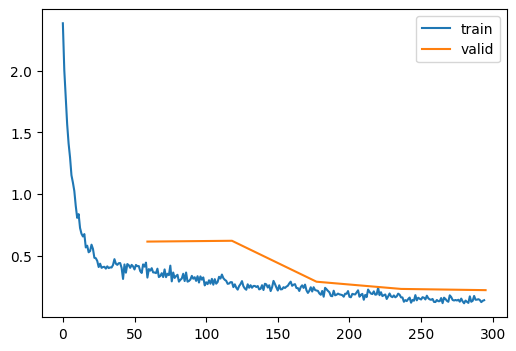

In [35]:
# Train for 5 epochs
learn.fit(epochs)

The timm ResNet is much larger and more sophisticated, so it should achieve better accuracy!

---
## Summary

### The Degradation Problem

Deeper networks don't always perform better:
- Not due to overfitting (training accuracy also drops)
- Due to optimization difficulty
- Hard for layers to learn identity mappings

### Skip Connections (Residual Learning)

Instead of learning `H(x)`, learn `F(x) = H(x) - x`:

```
output = F(x) + x
```

**Benefits:**
- If optimal mapping is identity, F(x) just needs to be 0
- Gradients flow directly through skip connections
- Enables training of very deep networks (100+ layers)

### ResBlock Structure

```
x ──┬──→ [Conv] → [BN] → [Act] → [Conv] → [BN] ──┬──→ [Act] → output
    │                                            │
    └─────────────── [Shortcut] ─────────────────┘

Shortcut:
- Same dimensions: Identity (just x)
- Different dimensions: 1x1 Conv + AvgPool
```

### Key Implementation Details

| Component | Purpose |
|-----------|--------|
| `_conv_block` | Two convs that learn the residual F(x) |
| `idconv` | 1x1 conv for channel projection (if needed) |
| `pool` | AvgPool for spatial downsampling (if needed) |
| Final activation | Applied AFTER adding skip connection |

### timm Library

Use `timm` for production:
- Hundreds of pre-implemented models
- Pre-trained weights available
- Well-tested implementations
- Easy to customize

```python
model = timm.create_model('resnet18d', in_chans=1, num_classes=10)
```

### Historical Significance

ResNets (2015) were revolutionary:
- Won ImageNet with 152 layers (vs previous ~20 layers)
- Introduced skip connections (now used everywhere)
- Enabled training of much deeper networks
- Still the backbone of many modern architectures

---
## Export

In [ ]:
import nbdev; nbdev.nbdev_export()